In [2]:
import os
from typing import Dict, Sequence, Optional

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from util.pcmdi_enso_reader import (
    ENSODiagReader
)

In [3]:
class ENSOPatternMapPlotter:
    """
    Plot 2D ENSO SST pattern maps for:
      - reference (obs)
      - hist ensemble mean
      - future ensemble mean

    Expects a data_dict with keys like:
      data_dict["reference"] : (lat, lon)
      data_dict["hist"]      : (member, lat, lon)
      data_dict["future"]    : (member, lat, lon)
    """

    def __init__(
        self,
        data_dict: Dict[str, xr.DataArray],
        fig_dir: str,
        plot_dict: Dict[str, dict],
        group_order: Sequence[str] = ("hist", "future"),
        obs_key: str = "reference",
        lat_name: str = "latitude",
        lon_name: str = "longitude_a",
    ):
        """
        Parameters
        ----------
        data_dict : dict
            Mapping from group key to DataArray.
            Must contain obs_key and all groups in group_order.
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling information keyed by group name, e.g.
              {
                "reference": {"label": "ERA-Interim", "color": "black"},
                "hist":      {"label": "E3SM (Historical)"},
                "future":    {"label": "E3SM (Near-Future)"},
              }
            Color is only used for titles/annotations; maps use cmap.
        group_order : sequence
            Model groups to plot after the reference.
        obs_key : str
            Key in data_dict for the observational reference.
        lat_name, lon_name : str
            Names of latitude and longitude coordinates in the DataArrays.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key
        self.lat_name    = lat_name
        self.lon_name    = lon_name

        # Build mean maps for each group (reference + ensemble means)
        self.mean_maps   = self._build_mean_maps()
        self.spread_maps = self._build_spread_maps()

    def _build_mean_maps(self) -> Dict[str, xr.DataArray]:
        """Return dict of 2D mean maps (lat, lon) for each key."""
        mean_maps = {}

        # ---- reference ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        ref = self.data_dict[self.obs_key]
        # average any extra dims beyond (lat, lon)
        extra_dims = [d for d in ref.dims if d not in (self.lat_name, self.lon_name)]
        if extra_dims:
            ref = ref.mean(dim=extra_dims)
        mean_maps[self.obs_key] = ref

        # ---- model groups ----
        for key in self.group_order:
            if key not in self.data_dict:
                raise ValueError(
                    f"Expected group '{key}' in data_dict, "
                    f"found keys: {list(self.data_dict.keys())}"
                )
            da = self.data_dict[key]
            # average over member and any extra dims beyond (lat, lon)
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if extra_dims:
                da = da.mean(dim=extra_dims)
            mean_maps[key] = da

        return mean_maps

    def _build_spread_maps(self) -> Dict[str, xr.DataArray]:
        """
        Return dict of ensemble spread (std) maps (lat, lon) for each model group.
        Reference/obs is omitted because it has no ensemble.
        """
        spread_maps = {}
        for key in self.group_order:
            if key not in self.data_dict:
                continue
            da = self.data_dict[key]

            # Treat any non-lat/lon dims (e.g., 'member', 'sample') as ensemble/sample dims
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if not extra_dims:
                # No ensemble dimension -> no spread
                continue

            spread_maps[key] = da.std(dim=extra_dims)
        return spread_maps

    def _get_panel_label(self, key: str) -> str:
        """Get human-readable label for each panel from plot_dict or the key."""
        style = self.plot_dict.get(key, {})
        return style.get("label", key)

    def plot_sst_map(
        self,
        filename: str = "enso_sst_pattern_hist_future_maps.pdf",
        cmap: str = "RdBu_r",
        mlevels: Optional[list] = None,
        title_prefix: str = "",
        figsize: tuple = (14, 3.5),
        fontz: int = 12,
        central_lon: float = 180.0,
        overlay_spread: bool = False,
        spread_quantile: float = 0.75,
        spread_level: float = None,
        fig_idx: int = 0,
    ):
        """
        Plot 3-panel ENSO SST pattern comparison with optional ensemble-spread overlay.
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        maps = [self.mean_maps[k] for k in panel_keys]

        lat = maps[0][self.lat_name].values
        lon = maps[0][self.lon_name].values

        # tick locations
        xticks = np.arange(np.floor(lon.min()), np.ceil(lon.max()), 30)
        yticks = np.arange(-15, 16, 10)

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = np.concatenate([m.values.ravel() for m in maps])
            finite = np.isfinite(all_vals)
            max_abs = np.nanmax(np.abs(all_vals[finite]))
            vmin = -max_abs
            vmax = max_abs
            # levels for pattern contours
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min (mlevels) 
            vmax = max (mlevels) 
        
        # ----- Determine spread contour levels (if overlay is requested) -----
        if overlay_spread and self.spread_maps:
            if spread_level is None:
                all_spread_vals = np.concatenate([
                    self.spread_maps[k].values.ravel()
                    for k in self.group_order
                    if k in self.spread_maps
                ])
                finite = np.isfinite(all_spread_vals)
                if np.any(finite):
                    spread_level = np.nanpercentile(
                        all_spread_vals[finite],
                        spread_quantile * 100.0,
                    )

        # ----- Setup figure -----
        fig = plt.figure(figsize=figsize)
        n = len(panel_keys)

        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        axes = []
        for i, key in enumerate(panel_keys):
            ax = fig.add_subplot(1, n, i + 1, projection=proj)
            ax.set_aspect("auto")
            axes.append(ax)   # <<< IMPORTANT: add axis to list

            da_map = self.mean_maps[key]
            label = self._get_panel_label(key)

            # Filled contour map instead of pcolormesh
            im = ax.contourf(
                lon, lat, da_map,
                levels=mlevels,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                transform=data_crs,
                extend="both",
            )

            # (optional but nice) thin contour outlines
            ax.contour(
                lon, lat, da_map,
                levels=mlevels,
                colors="k",
                linewidths=0.3,
                transform=data_crs,
            )

            ax.coastlines(linewidth=0.5)
            ax.set_extent(
                [lon.min(), lon.max(), lat.min(), lat.max()],
                crs=data_crs,
            )

            # Latitude / longitude ticks and labels
            ax.set_xticks(xticks, crs=data_crs)
            ax.set_yticks(yticks, crs=data_crs)
            ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f"))
            ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f"))
            
            # --- optional: overlay ensemble spread as hatched dots ---
            if overlay_spread and key in self.spread_maps:
                spread = self.spread_maps[key]
                
                if spread_level is not None:
                    # mask below threshold
                    spread_mask = np.where(spread > spread_level, 1, np.nan)
            
                    ax.contourf(
                        lon, lat, spread_mask,
                        levels=[0.5, 1.5],      # two levels: masked vs hatched
                        hatches=["...."],       # dotted hatching
                        colors="none",          # no fill color
                        transform=data_crs,
                    )

            panel_label = f"({chr(97 + i + fig_idx)}) {label}"
            ax.set_title(panel_label, fontsize=fontz * 1.0, loc="left")
            ax.tick_params(labelsize=fontz * 0.95)

            if i == 0:
                ax.set_ylabel("Latitude", fontsize=fontz * 1.0)
            ax.set_xlabel("Longitude", fontsize=fontz * 1.0)

        # ----- Colorbar (centered below all panels) -----
        cbar = fig.colorbar(
            im,
            ax=axes,  # now non-empty
            orientation="horizontal",
            fraction=0.05,
            pad=0.12,
            aspect=40,
        )

        cbar.set_label("SST pattern (°C)", fontsize=fontz * 1.0)
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        # Manual layout to avoid big white space and keep room for colorbar
        fig.subplots_adjust(
            left=0.06,
            right=0.98,
            bottom=0.2,
            top=0.82,
            wspace=0.15,
        )

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=150, format="pdf")
        print(f"Saved ENSO SST pattern map figure to {out_path}")
        return fig, axes
        
    def plot_multi_sst_map(
        self,
        other_plotter,
        var_labels=None,
        filename="enso_sst_pattern_multi.pdf",
        figsize=(15, 8),
        fontz=14,
        cmap="RdBu_r",
        mlevels=None,
        central_lon=180.0,
        overlay_spread=True,
        spread_quantile=0.75,
        spread_level=0.1,
        fig_idx_start=0,
        fig_aspect=0.45,
        fig_format="pdf",
        fig_dpi=300,
        cb_label="SST pattern (°C)",
    ):
        """
        Plot self and another plotter together in 2×3 layout.

        Row 1 = self
        Row 2 = other_plotter
        """
        # both plotters must share lat/lon
        panel_keys = [self.obs_key] + list(self.group_order)
        ncols = len(panel_keys)
        nrows = 2

        # lat/lon
        lat = self.mean_maps[self.obs_key][self.lat_name].values
        lon = self.mean_maps[self.obs_key][self.lon_name].values

        if mlevels is None:
            # gather values for global color limits
            all_vals = []
            for mp in [self, other_plotter]:
                for key in panel_keys:
                    all_vals.append(mp.mean_maps[key].values.ravel())
            all_vals = np.concatenate(all_vals)
            finite = np.isfinite(all_vals)
            vmax = np.nanmax(np.abs(all_vals[finite]))
            vmin = -vmax
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min (mlevels) 
            vmax = max (mlevels) 
        
        # ticks
        xticks = np.arange(np.floor(lon.min()), np.ceil(lon.max()), 30)
        yticks = np.arange(-10, 11, 10)

        # create figure
        fig = plt.figure(figsize=figsize)
        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        # loop rows
        plotters = [self, other_plotter]
        axes = []
        im = None
        
        # build cmap with distinct extension colors
        base_cmap = plt.get_cmap(cmap).copy()
        base_cmap.set_under("#08306B")   # deep navy for < vmin
        base_cmap.set_over("#67000D")    # deep maroon for > vmax

        for row in range(nrows):
            mp = plotters[row]
            for col, key in enumerate(panel_keys):
                idx = row * ncols + col + 1
                ax = fig.add_subplot(nrows, ncols, idx, projection=proj)
                ax.set_aspect("auto")        # keep data aspect free
                ax.set_box_aspect(fig_aspect)  # FIX panel shape independent of figsize
                axes.append(ax)
                da_map = mp.mean_maps[key]

                # filled contours
                im = ax.contourf(
                    lon, lat, da_map,
                    levels=mlevels,
                    cmap=base_cmap,
                    vmin=vmin, vmax=vmax,
                    transform=data_crs,
                    extend="both",
                )

                # thin outlines
                ax.contour(
                    lon, lat, da_map,
                    levels=mlevels,
                    colors="k",
                    linewidths=0.3,
                    transform=data_crs,
                )

                ax.coastlines(linewidth=0.5)
                ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=data_crs)

                # ticks
                ax.set_yticks(yticks, crs=data_crs)
                ax.set_xticks(xticks, crs=data_crs)
                ax.xaxis.set_major_formatter(LongitudeFormatter(".0f"))
                ax.yaxis.set_major_formatter(LatitudeFormatter(".0f"))

                # spread hatching
                if overlay_spread and key in mp.spread_maps:
                    spread = mp.spread_maps[key]
                
                    if spread_level is None:
                        vals = spread.values                 # <- go to numpy
                        finite = np.isfinite(vals)
                        if np.any(finite):
                            spread_level = np.nanpercentile(
                                vals[finite],
                                spread_quantile * 100.0,
                            )
                
                    spread_mask = np.where(spread.values > spread_level, 1, np.nan)
                    ax.contourf(
                        lon, lat, spread_mask,
                        levels=[0.5, 1.5],
                        hatches=["...."],
                        colors="none",
                        transform=data_crs,
                    )
                    
                # panel label (a, b, c, d, e, f)
                label = mp._get_panel_label(key)
                panel_label = f"({chr(fig_idx_start + idx - 1 + 97)}) {label}"
                ax.set_title(panel_label, fontsize=fontz, loc="left")
                ax.set_title(f"{var_labels[row]}",fontsize=fontz, loc="right")
                ax.tick_params(labelsize=fontz * 0.95)

                if col == 0:
                    ax.set_ylabel("Latitude", fontsize=fontz)
                ax.set_xlabel("Longitude", fontsize=fontz)

        fig.subplots_adjust(
            left=0.06,
            right=0.98,
            bottom=0.23,      # more room so cb sits lower
            top=0.92,
            hspace=0.10,      # reduce space between rows
            wspace=0.18,
        )
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([1.0, 0.35, 0.015, 0.50])
        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",   # ← change from "horizontal"
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        fig.savefig(filename, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.05)
        
        print("Saved:", os.path.join(self.fig_dir, filename))


Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_tel: ['enso_amplitude', 'enso_pr_map_djf', 'enso_pr_map_jja', 'enso_seasonality', 'enso_sst_lon_rmse', 'enso_sst_map_djf', 'enso_sst_map_jja']

>>> Loading target_var = Nina_sst_map
processing period: hist
processing period: future
  Group: hist
  Group: future

✓ All target_var successfully read.

Variable: Nina_sst_map
  Group: reference
type=DataArray | shape=(30, 165) | dims=('latitude', 'longitude_a')
  Group: hist
type=DataArray | shape=(25, 30, 165) | dims=('member', 'latitude', 'longitude_a')
  Group: future
type=DataArray | shape=(25, 30, 165) | dims=('member', 'latitude', 'longitude_a')
Nina_sst_map hist min spread = 0.04534327983856201 max spread = 0.48729944229125977
Nina_sst_map future min spread = 0.043604157865047455 max spread = 0.5233585834503174

>>> Loading target_var = Nino_sst_map
processing period: hist
processing period: future
  Group: hist
  Group: future

✓ All target_var successfu

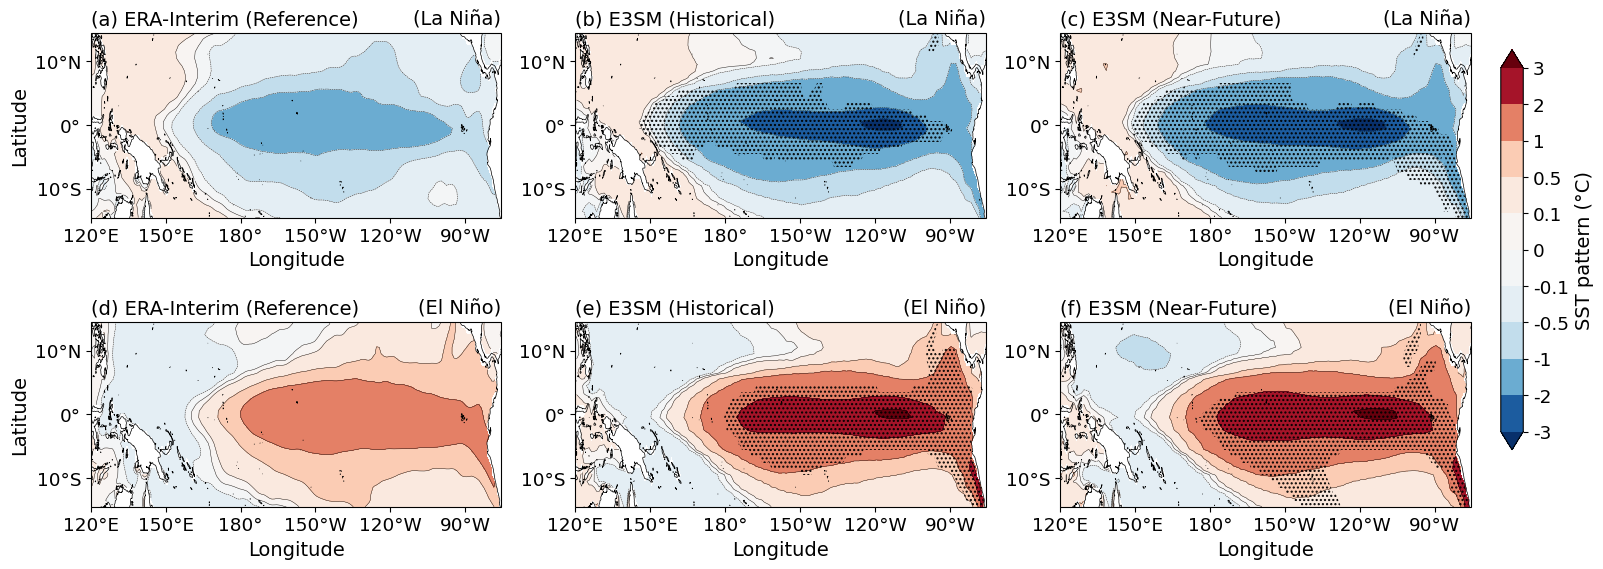

In [4]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    # ---- Pair experiments consistently (order matters) ----
    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]

    members = None
    verbose = False
    diag_print = True 
    
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )
    
    target_metric_dict = {
        "enso_sst_lon_rmse" : {
            "vars": ["Nina_sst_map","Nino_sst_map"],
            "vmap" : {
                "Nina_sst_map": "(La Niña)",
                "Nino_sst_map": "(El Niño)",
            },
            "obs" : {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "group": "ENSO_tel",
            "label" : r"ENSO Feedback (SST$\rightarrow$THF)",
            "unit" : r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin" : -24,
            "ymax" : 1,
            "rtol" : 1e-1
        },
    }
    
    pool_members_to_samples = False

    for i,target_metric in enumerate(target_metric_dict.keys()):
        
        target_var_list = target_metric_dict[target_metric]['vars']
        target_obs_dict = target_metric_dict[target_metric]['obs'] 
        target_group = target_metric_dict[target_metric]['group']  
        target_rtol = target_metric_dict[target_metric]['rtol']
        target_ymin = target_metric_dict[target_metric]['ymin']
        target_ymax = target_metric_dict[target_metric]['ymax']
        target_label = target_metric_dict[target_metric]['label']
        target_unit = target_metric_dict[target_metric]['unit']
        var_label_map = target_metric_dict[target_metric]['vmap']
    
        # ---- Sanity checks ----
        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))
    
        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
    
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")
    
        # ----------------------------------------------------
        # Loop through target variable list and plot 
        # ----------------------------------------------------
        plot_dict = {
            "reference": {
                "label": f"{target_obs_dict['hist']} (Reference)",
            },
            "hist": {
                "label": "E3SM (Historical)",
            },
            "future": {
                "label": "E3SM (Near-Future)",
            },
        }
        
        title_prefix = ""  # or whatever you like
        figure_name  = f"enso_{target_metric}_hist_future_maps.pdf"
        
        overlay_spread=True        # NEW: show contours
        spread_quantile=0.75       # e.g., 75th percentile of spread
        spread_level=None         # explicit levels in °C; if None then use spread_quantile
        figure_format = "pdf"
        figure_dpi = 300 
        figsize=(15, 8)
        fontz=14
        
        obs_key="reference"
        lat_name="latitude"
        lon_name="longitude_a"
        make_single = False
        make_combine = True
    
        levels = [-3,-2,-1,-0.5,-0.1,0,0.1,0.5,1,2,3] 
    
        plotters = []
        var_labels = []
        for kk,target_var in enumerate(target_var_list):
            print(f"\n>>> Loading target_var = {target_var}")
            data_dict = {} 
            
            # Load model + obs using your working function
            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
            )
    
            # observation only has one member and is identical for historical and near-future
            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True,rtol=1e-3, atol=0.0,
                pool_ensemble = pool_members_to_samples, 
            )
            
            # If we get here, all obs are identical
            # ref is the DataArray you want to keep
            data_dict[obs_key] = ref
            
            for group, member_dict in dm.items():
                print(f"  Group: {group}")
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)  
                data_dict[group] = pooled
                
            print("\n✓ All target_var successfully read.")
        
            if diag_print: 
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    # da is an xarray DataArray or Dataset
                    shape = getattr(da, "shape", None)
                    dims  = getattr(da, "dims", None)
                    print(f"type={type(da).__name__} | shape={shape} | dims={dims}")
                    
            map_plotter = ENSOPatternMapPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,       
                obs_key=obs_key,
                lat_name=lat_name,
                lon_name=lon_name,
            )
            plotters.append(map_plotter)
            var_labels.append(var_label_map[target_var])
            
            # If you still want the single-row figure for each variable:
            if make_single:
                map_plotter.plot_sst_map(
                    filename=f"{target_var}_{figure_name}",
                    title_prefix=title_prefix,
                    figsize=figsize,
                    fontz=fontz,
                    overlay_spread=overlay_spread,
                    spread_quantile=spread_quantile,
                    spread_level=spread_level,
                    fig_idx=len(target_var_list) * kk,   # if you care about global panel labels
                )
                
            for g in GROUP:
                s = map_plotter.spread_maps[g]
                print(
                    target_var, g,
                    "min spread =", float(s.min()),
                    "max spread =", float(s.max())
                )
                
        # Finally: combined panel figure
        if make_combine:
            plotters[0].plot_multi_sst_map(
                other_plotter=plotters[1],
                var_labels=var_labels,
                filename=figure_name,
                figsize=figsize,
                fontz=fontz,
                overlay_spread=overlay_spread,
                spread_quantile=spread_quantile,
                spread_level=spread_level,
                mlevels=levels,
                fig_format=figure_format,
                fig_dpi = figure_dpi 
            )
